# Spherical Fourier-Bessel $C_\ell(k)$ for the Ly-$\alpha$ Forest: Periodic Box

**Pipeline:** 3D GRF → extract sightlines → LOS DFT → SHT → pseudo-$C_\ell(k)$ → theory comparison

**Key facts for periodic box with uniform weights:**
- Data weights: $w_j = \text{FT}[\delta_F]_j(k)$ — the LOS DFT of flux fluctuations
- Mask weights: $m_j = \text{FT}[1]_j(k=0) = N$ (sum of ones), zero at $k \neq 0$
- pseudo-$C_\ell = |a_{\ell m}^{\rm data}|^2 / (2\ell+1)$ — **no D−R subtraction** for Ly-$\alpha$
- Theory: $C_\ell^{\rm true}(k) = P_F(\ell/\bar\chi, k) / (32\pi^3 \bar\chi^2)$ for use with `MaskDeconvolution`

## 0. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
import sys, os, time, gc

# Add project paths
sys.path.insert(0, os.path.join(os.getcwd(), '..'))
sys.path.insert(0, os.getcwd())

from sht.sht import DirectSHT
from sht.mask_deconvolution import MaskDeconvolution
from sht.theory_lya import (theory_cl_for_deconvolution,
                             compute_chi_bar_from_grid)
import GRF_class as my_GRF
import SHT_lya as sht_lya
import fast_Wigner3j as Wigner3j

%matplotlib inline
plt.rcParams.update({'font.size': 13, 'figure.figsize': (10, 6)})

JAX not found. Falling back to NumPy.
JAX not found. Falling back to NumPy.


### Parameters

In [2]:
# GRF / survey settings
add_rsd_  = False       # set True to include Kaiser RSD
num_qso   = 9797        # requested number of sightlines
chi_shift = 5000.0      # LOS displacement (Mpc/h)

# SHT settings
Nl         = 500
lambda_max = 1000
Nx         = 2 * Nl
xmax       = 3. / 4.
NperBin    = 32          # bandpower bin width

# k=0 is the only mode with non-zero mask FT for periodic box
k_idx = 0

# Number of independent GRF realisations (increase for smaller error bars)
num_sim = 20

print(f'Nl={Nl}, lambda_max={lambda_max}, num_qso={num_qso}')
print(f'num_sim={num_sim}, k_idx={k_idx}, add_rsd={add_rsd_}')

Nl=500, lambda_max=1000, num_qso=9797
num_sim=20, k_idx=0, add_rsd=False


## 1. Simulation Loop — measured pseudo-$C_\ell(k{=}0)$

For each seed: generate 3D GRF, extract sightlines, LOS DFT, SHT at $k{=}0$.

Accumulate `hp.alm2cl(hdat)` across realisations.

In [3]:
sht_eng = DirectSHT(Nl, Nx, xmax)
print(f'DirectSHT: Nl={Nl}, Nx={Nx}, xmax={xmax}')

DirectSHT: Nl=500, Nx=1000, xmax=0.75


In [4]:
cl_stack = []  # measured pseudo-Cl(k=0)
wl_ref   = None

for sim_idx in range(num_sim):
    seed = 1000 + sim_idx
    t0 = time.time()

    GRF = my_GRF.PowerSpectrumGenerator(add_rsd=add_rsd_, seed=seed)
    all_x, all_y, all_z, all_w_rand, all_w_gal, Nskew = GRF.process_skewers(
        Nskew=num_qso, shift=chi_shift)
    all_theta, all_phi = GRF.compute_theta_phi_skewer_start(
        all_x[:, 0], all_y[:, 0], all_z[:, 0])
    chi_grid = all_x[0, :]
    delta_F  = all_w_gal - 1.0

    # LOS DFT — unnormalised, real-only output (original convention)
    k_arr, FT_mask, FT_delta = sht_lya.compute_dft(chi_grid, all_w_rand, delta_F)
    N = chi_grid.size

    # Periodic-box sanity check
    if sim_idx == 0:
        assert np.allclose(FT_mask[:, 0], N), f'FT_mask[:,0] != N'
        assert np.allclose(FT_mask[:, 1], 0, atol=1e-10), 'FT_mask[:,1] != 0'
        print(f'  ✓ FT_mask[:,0]={N}, FT_mask[:,k≠0]=0  (periodic box)')

    # SHT + pseudo-Cl
    hdat = sht_eng(all_theta, all_phi, FT_delta[:, k_idx])
    cl   = hp.alm2cl(hdat)[:Nl]
    cl_stack.append(cl)

    # Save geometry from first sim (process_skewers uses a fixed random seed
    # for sightline selection, so angular positions are identical across sims)
    if sim_idx == 0:
        hran       = sht_eng(all_theta, all_phi, FT_mask[:, k_idx])
        wl_ref     = hp.alm2cl(hran)[:Nl]
        chi_grid_0 = chi_grid
        theta_0, phi_0 = all_theta, all_phi
        Nskew_0    = Nskew
        plin_ref   = GRF.plin
        b1_ref     = GRF.my_bias

    del GRF, all_x, all_y, all_z, all_w_rand, all_w_gal, delta_F, FT_mask, FT_delta
    gc.collect()
    print(f'  sim {sim_idx}: seed={seed}, Nskew={Nskew}, dt={time.time()-t0:.1f}s')

cl_stack = np.array(cl_stack)
cl_mean  = np.mean(cl_stack, axis=0)
cl_std   = np.std(cl_stack, axis=0)

dchi    = chi_grid_0[1] - chi_grid_0[0]
L_box   = N * dchi
chi_bar = compute_chi_bar_from_grid(chi_grid_0)
print(f'\nNskew={Nskew_0}, N={N}, L_box={L_box:.1f}, dchi={dchi:.4f}, chi_bar={chi_bar:.1f}')
print(f'b1={b1_ref}')

Displacing box by 5.000e+03
  ✓ FT_mask[:,0]=512, FT_mask[:,k≠0]=0  (periodic box)
  sim 0: seed=1000, Nskew=9600, dt=28.8s
Displacing box by 5.000e+03
  sim 1: seed=1001, Nskew=9600, dt=26.2s
Displacing box by 5.000e+03
  sim 2: seed=1002, Nskew=9600, dt=22.9s
Displacing box by 5.000e+03
  sim 3: seed=1003, Nskew=9600, dt=21.7s
Displacing box by 5.000e+03
  sim 4: seed=1004, Nskew=9600, dt=22.8s
Displacing box by 5.000e+03
  sim 5: seed=1005, Nskew=9600, dt=23.1s
Displacing box by 5.000e+03
  sim 6: seed=1006, Nskew=9600, dt=21.8s
Displacing box by 5.000e+03
  sim 7: seed=1007, Nskew=9600, dt=22.5s
Displacing box by 5.000e+03
  sim 8: seed=1008, Nskew=9600, dt=22.0s
Displacing box by 5.000e+03
  sim 9: seed=1009, Nskew=9600, dt=22.8s
Displacing box by 5.000e+03
  sim 10: seed=1010, Nskew=9600, dt=22.5s
Displacing box by 5.000e+03
  sim 11: seed=1011, Nskew=9600, dt=23.3s
Displacing box by 5.000e+03
  sim 12: seed=1012, Nskew=9600, dt=23.3s
Displacing box by 5.000e+03
  sim 13: seed=10

### Diagnostic: sightline sky positions & example LOS

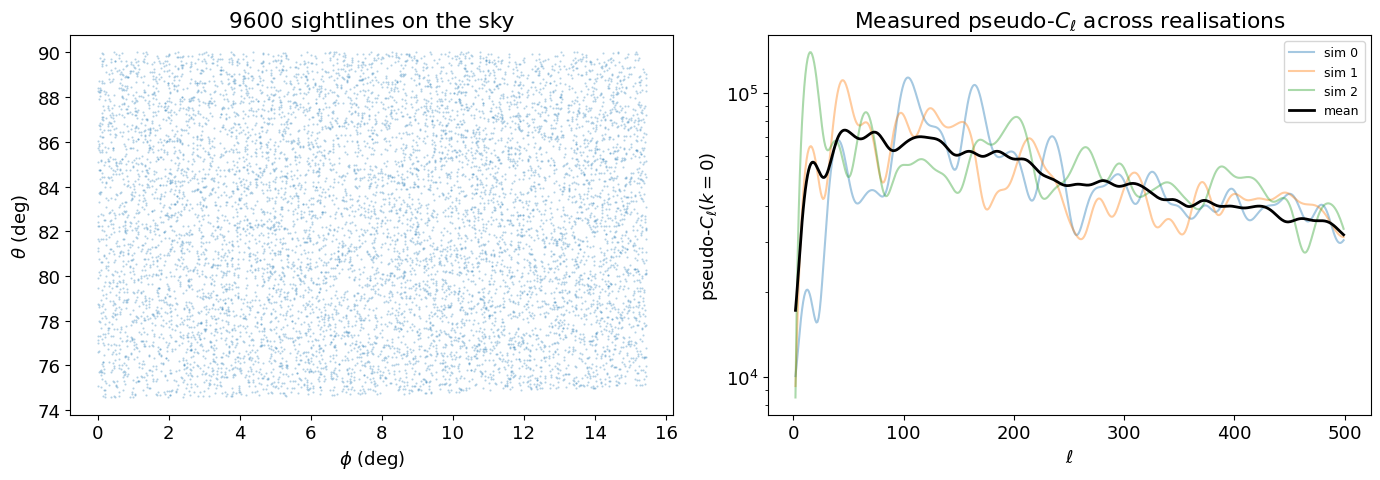

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(np.degrees(phi_0), np.degrees(theta_0), s=0.3, alpha=0.3)
ax.set_xlabel(r'$\phi$ (deg)')
ax.set_ylabel(r'$\theta$ (deg)')
ax.set_title(f'{Nskew_0} sightlines on the sky')

ax = axes[1]
ells = np.arange(Nl)
for i in range(min(num_sim, 3)):
    ax.semilogy(ells[2:], cl_stack[i, 2:], alpha=0.4, label=f'sim {i}')
ax.semilogy(ells[2:], cl_mean[2:], 'k-', lw=2, label='mean')
ax.set_xlabel(r'$\ell$')
ax.set_ylabel(r'pseudo-$C_\ell(k{=}0)$')
ax.set_title('Measured pseudo-$C_\ell$ across realisations')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 2. Pair-Counting Theory (original code approach)

The original pipeline theory prediction is:

$$C_{\rm theory} = \frac{\mathbf{M}_{pk} \cdot \text{PLKjKk}}{4\pi \cdot 2\pi\bar\chi^2},$$

plotted as $C_{\rm theory}/(4\pi)^2$, where:
- $\mathbf{M}_{pk}[\ell, \lambda] = \frac{2\lambda+1}{4\pi}\sum_L (2L+1)\, P_F(L/\bar\chi)\,(3j)^2$ — Wigner coupling with $P_F$ as weights
- $\text{PLKjKk}[\lambda] = K_jK_k \sum_{j,k} P_\lambda(\cos\theta_{jk})$ — pair-counting angular window

### Why the factor $1/(32\pi^3)$?

Using two verified algebraic identities:

1. $\text{PLKjKk}[\lambda] = 4\pi \, W_\lambda$  (pair count = $4\pi$ × angular $C_\ell$ of mask)
2. $\mathbf{M}_{pk} \cdot W = \mathbf{M}_{W} \cdot P$  (Wigner 3j symmetry: spectrum and window are exchangeable)

we get

$$\frac{C_{\rm theory}}{(4\pi)^2} = \frac{\mathbf{M}_W \cdot P}{2\pi\bar\chi^2 \cdot (4\pi)^2} = \sum_L M_{\ell L} \frac{P_L}{32\pi^3 \bar\chi^2}$$

Comparing to the MASTER relation $\langle\tilde{C}_\ell\rangle = \sum_L M_{\ell L} C_L^{\rm true}$ identifies:

$$C_L^{\rm true} = \frac{P_F(L/\bar\chi, k)}{32\pi^3 \bar\chi^2} = \frac{P_F}{\underbrace{2\pi}_{\text{sFB projection}} \cdot \underbrace{4\pi}_{\text{addition thm}} \cdot \underbrace{(4\pi)}_{\text{coupling norm}} \cdot \bar\chi^2}$$

Each factor has a standard origin in the spherical harmonic normalization conventions.

In [6]:
# Pair counting: PLKjKk[λ] = KjKk × Σ_{j,k} Pλ(cos θ_{jk})
nhat = sht_lya.compute_nhat(theta_0, phi_0)
cos_theta = np.dot(nhat, nhat.T)
KjKk = N**2  # periodic box: FT_mask[:,0] = N
del nhat; gc.collect()

t0 = time.time()
print('Computing pair-counting Legendre sums...', end='', flush=True)
PLKjKk = sht_lya.legendre_polynomials_sum(lambda_max, cos_theta, KjKk)[:lambda_max]
print(f'done ({time.time()-t0:.1f}s)')
del cos_theta; gc.collect()

# Verify identity: PLKjKk[λ] = 4π × wl_ref[λ]
ratio_check = PLKjKk[:10] / (4 * np.pi * wl_ref[:10])
print(f'✓ PLKjKk / (4π × wl_ref) = {ratio_check[:5].round(6)} (should be 1.0)')

Computing pair-counting Legendre sums...

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


done (123.8s)
✓ PLKjKk / (4π × wl_ref) = [1. 1. 1. 1. 1.] (should be 1.0)


In [7]:
# P(L/chi_bar) with bias factor
L_range = np.arange(lambda_max, dtype=float)
pk_L = b1_ref**2 * plin_ref(L_range / chi_bar)

# Wigner coupling matrix with P_F as weights
t0 = time.time()
couple_pk  = Wigner3j.CoupleMat(lambda_max, pk_L)
coupling_pk = couple_pk.compute_matrix()
print(f'Coupling matrix computed in {time.time()-t0:.1f}s')

# Theory (original formula)
C_theory      = coupling_pk @ PLKjKk / (4*np.pi) / (2*np.pi * chi_bar**2)
C_theory_plot = C_theory / (4*np.pi)**2

Coupling matrix computed in 0.5s


## 3. Binning & Comparison

In [8]:
MD   = MaskDeconvolution(Nl, wl_ref)
bins = MD.binning_matrix('linear', 0, NperBin)
ells = np.arange(Nl, dtype=float)
binned_ells = bins @ ells

binned_theory = bins @ C_theory_plot[:Nl]
binned_mean   = bins @ cl_mean
binned_std    = bins @ (cl_std / np.sqrt(num_sim))

print(f'{"ell":>8s} {"theory":>12s} {"measured":>12s} {"ratio":>8s} {"SNR":>6s}')
print('-' * 50)

ratios = []
for i in range(min(15, len(binned_ells))):
    if binned_theory[i] > 0:
        r   = binned_mean[i] / binned_theory[i]
        snr = binned_mean[i] / binned_std[i] if binned_std[i] > 0 else np.inf
        ratios.append(r)
        print(f'{binned_ells[i]:8.1f} {binned_theory[i]:12.4e} '
              f'{binned_mean[i]:12.4e} {r:8.4f} {snr:6.1f}')

mean_ratio_low = np.mean([r for r, e in zip(ratios[1:9], binned_ells[1:9])])
mean_ratio_all = np.mean(ratios[1:])
print(f'\nMean ratio (ell < 288, excl. monopole) = {mean_ratio_low:.4f}')
print(f'Mean ratio (all bins, excl. monopole)   = {mean_ratio_all:.4f}')

Precomputing Wigner 3j symbols...
Computing the mode-coupling matrix...
     ell       theory     measured    ratio    SNR
--------------------------------------------------
    15.5   4.2812e+04   4.3849e+04   1.0242    7.3
    47.5   6.5538e+04   6.8709e+04   1.0484   15.6
    79.5   7.5529e+04   6.8179e+04   0.9027   14.8
   111.5   7.5646e+04   6.8628e+04   0.9072   15.8
   143.5   7.0331e+04   6.3752e+04   0.9064   19.4
   175.5   6.2950e+04   6.1285e+04   0.9735   21.0
   207.5   5.5709e+04   5.7660e+04   1.0350   24.5
   239.5   4.9715e+04   4.9069e+04   0.9870   22.8
   271.5   4.5228e+04   4.8190e+04   1.0655   28.9
   303.5   4.2031e+04   4.7467e+04   1.1294   33.1
   335.5   3.9627e+04   4.2942e+04   1.0837   33.0
   367.5   3.7540e+04   4.0884e+04   1.0891   37.9
   399.5   3.5402e+04   3.9801e+04   1.1242   32.1
   431.5   3.3045e+04   3.8363e+04   1.1609   37.2
   463.5   3.0514e+04   3.5743e+04   1.1714   30.8

Mean ratio (ell < 288, excl. monopole) = 0.9782
Mean ratio (

## 4. The Money Plot — Measured vs. Theory

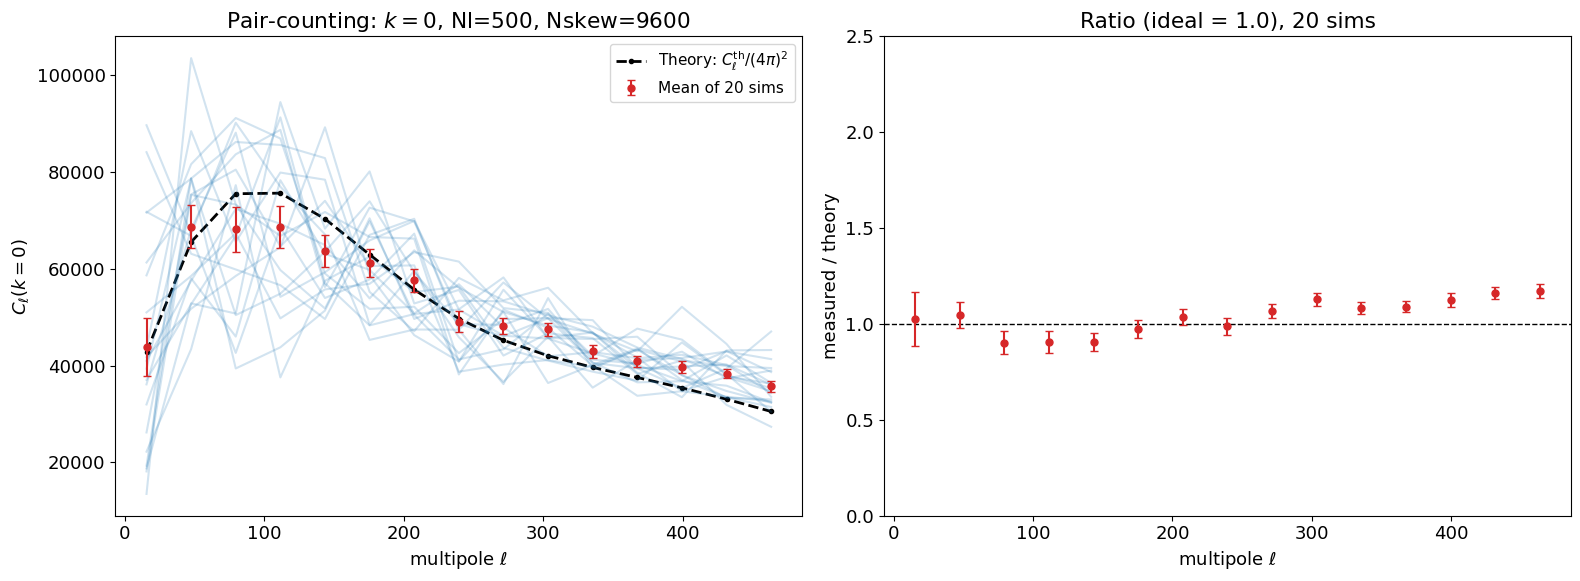

Saved plots/money_plot_k0.pdf


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: absolute comparison ---
ax = axes[0]
ax.plot(binned_ells, binned_theory, 'k.--', lw=2,
        label=r'Theory: $C_\ell^{\rm th}/(4\pi)^2$')

for i in range(num_sim):
    ax.plot(binned_ells, bins @ cl_stack[i], 'C0-', alpha=0.2)

ax.errorbar(binned_ells, binned_mean, yerr=binned_std,
            fmt='C3o', ms=5, capsize=3,
            label=f'Mean of {num_sim} sims')
ax.set_xlabel(r'multipole $\ell$')
ax.set_ylabel(r'$C_\ell(k{=}0)$')
ax.set_title(f'Pair-counting: $k{{=}}0$, Nl={Nl}, Nskew={Nskew_0}')
ax.legend(fontsize=11)

# --- Right: ratio ---
ax = axes[1]
ax.axhline(1.0, color='k', ls='--', lw=1)
ax.errorbar(binned_ells, np.array(ratios),
            yerr=binned_std[:len(ratios)] / binned_theory[:len(ratios)],
            fmt='C3o', ms=5, capsize=3)
ax.set_xlabel(r'multipole $\ell$')
ax.set_ylabel(r'measured / theory')
ax.set_ylim(0, 2.5)
ax.set_title(f'Ratio (ideal = 1.0), {num_sim} sims')

plt.tight_layout()
plt.savefig('plots/money_plot_k0.pdf', bbox_inches='tight', dpi=150)
plt.show()
print('Saved plots/money_plot_k0.pdf')

## 5. MaskDeconvolution Approach

Using $C_\ell^{\rm true} = P_F(\ell/\bar\chi, k)\;/\;(32\pi^3 \bar\chi^2)$ with the `MaskDeconvolution` forward model.

Both the measurement and theory are binned + deconvolved via `MD(pseudo_Cl, bins)` and `MD.convolve_theory_Cls(C_true, bins)`.

In [10]:
# C_true for MaskDeconvolution
cl_true_md = b1_ref**2 * plin_ref(ells / chi_bar) / (32 * np.pi**3 * chi_bar**2)

# Deconvolved theory
ells_dec, theory_dec = MD.convolve_theory_Cls(cl_true_md, bins)

# Deconvolved measurement
ells_meas, meas_dec = MD(cl_mean, bins)

# Per-realisation scatter for error bars
meas_dec_stack = []
for i in range(num_sim):
    _, md_i = MD(cl_stack[i], bins)
    meas_dec_stack.append(md_i)
meas_dec_stack = np.array(meas_dec_stack)
meas_dec_std = np.std(meas_dec_stack, axis=0) / np.sqrt(num_sim)

print(f'{"ell":>8s} {"theory_dec":>12s} {"meas_dec":>12s} {"ratio":>8s}')
print('-' * 44)
ratios_md = []
for i in range(min(15, len(ells_dec))):
    if theory_dec[i] > 0:
        r = meas_dec[i] / theory_dec[i]
        ratios_md.append(r)
        print(f'{ells_dec[i]:8.1f} {theory_dec[i]:12.4e} '
              f'{meas_dec[i]:12.4e} {r:8.4f}')

print(f'\nMean ratio (excl. monopole) = {np.mean(ratios_md[1:]):.4f}')

     ell   theory_dec     meas_dec    ratio
--------------------------------------------
    15.5   9.4082e-10   1.0878e-09   1.1562
    47.5   2.1560e-09   2.5466e-09   1.1811
    79.5   2.5530e-09   2.3236e-09   0.9101
   111.5   2.5470e-09   2.4346e-09   0.9558
   143.5   2.3253e-09   2.1830e-09   0.9388
   175.5   2.0289e-09   2.1295e-09   1.0496
   207.5   1.7455e-09   2.0399e-09   1.1687
   239.5   1.5173e-09   1.6038e-09   1.0571
   271.5   1.3521e-09   1.6490e-09   1.2196
   303.5   1.2399e-09   1.6669e-09   1.3444
   335.5   1.1586e-09   1.4512e-09   1.2526
   367.5   1.0886e-09   1.4012e-09   1.2871
   399.5   1.0188e-09   1.3892e-09   1.3636
   431.5   9.1966e-10   1.3338e-09   1.4504
   463.5   9.6289e-10   1.4857e-09   1.5430

Mean ratio (excl. monopole) = 1.1944


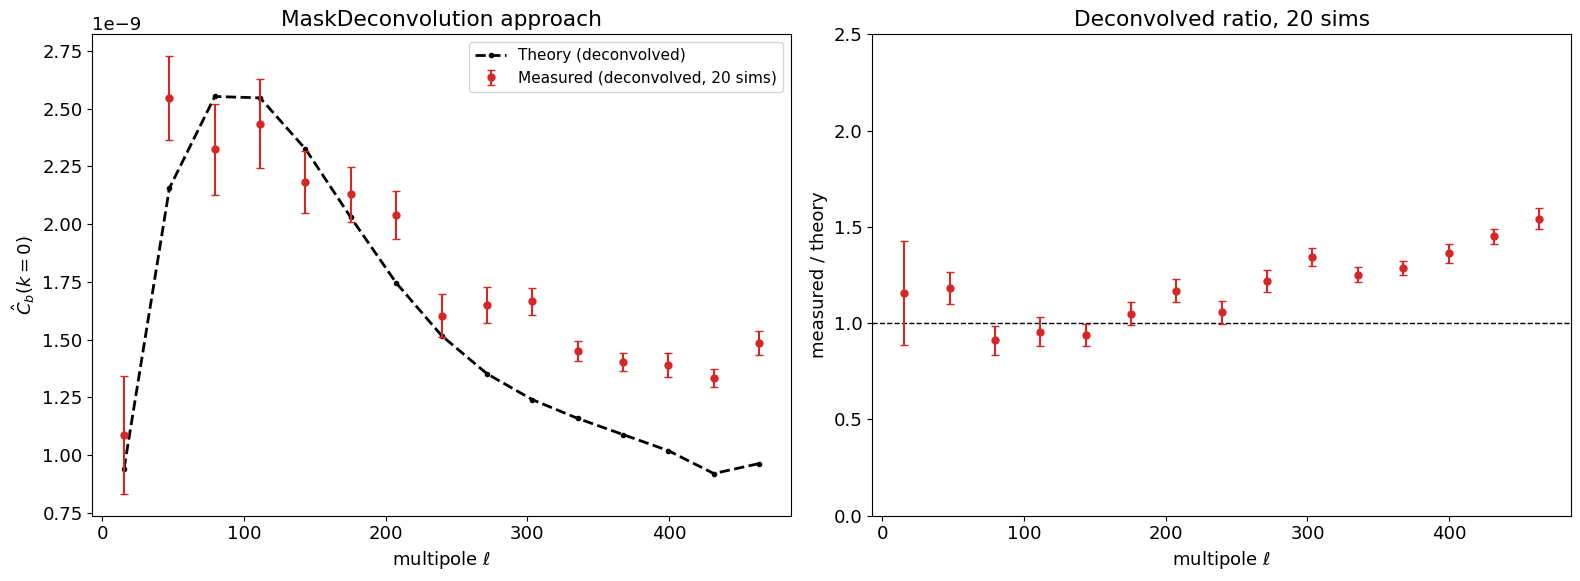

Saved plots/money_plot_deconv_k0.pdf


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
ax.plot(ells_dec, theory_dec, 'k.--', lw=2, label='Theory (deconvolved)')
ax.errorbar(ells_meas, meas_dec, yerr=meas_dec_std,
            fmt='C3o', ms=5, capsize=3,
            label=f'Measured (deconvolved, {num_sim} sims)')
ax.set_xlabel(r'multipole $\ell$')
ax.set_ylabel(r'$\hat{C}_b(k{=}0)$')
ax.set_title('MaskDeconvolution approach')
ax.legend(fontsize=11)

ax = axes[1]
ax.axhline(1.0, color='k', ls='--', lw=1)
ax.errorbar(ells_dec[:len(ratios_md)], ratios_md,
            yerr=meas_dec_std[:len(ratios_md)] / theory_dec[:len(ratios_md)],
            fmt='C3o', ms=5, capsize=3)
ax.set_xlabel(r'multipole $\ell$')
ax.set_ylabel('measured / theory')
ax.set_ylim(0, 2.5)
ax.set_title(f'Deconvolved ratio, {num_sim} sims')

plt.tight_layout()
plt.savefig('plots/money_plot_deconv_k0.pdf', bbox_inches='tight', dpi=150)
plt.show()
print('Saved plots/money_plot_deconv_k0.pdf')

## 6. Angular Window Diagnostics

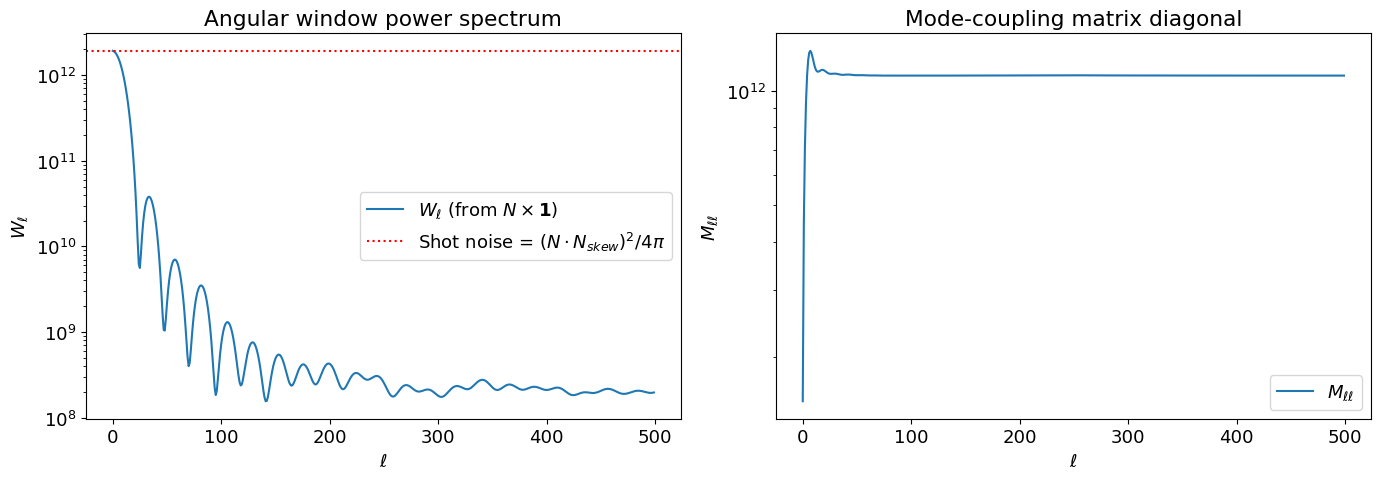

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.semilogy(ells, wl_ref, label=r'$W_\ell$ (from $N \times \mathbf{1}$)')
sn = (N * Nskew_0)**2 / (4 * np.pi)
ax.axhline(sn, color='r', ls=':', label=f'Shot noise = $(N \cdot N_{{skew}})^2 / 4\pi$')
ax.set_xlabel(r'$\ell$')
ax.set_ylabel(r'$W_\ell$')
ax.set_title('Angular window power spectrum')
ax.legend()

ax = axes[1]
# Mode coupling matrix diagonal
Mll = MD.Mll
ax.semilogy(ells, np.diag(Mll), label=r'$M_{\ell\ell}$')
ax.set_xlabel(r'$\ell$')
ax.set_ylabel(r'$M_{\ell\ell}$')
ax.set_title('Mode-coupling matrix diagonal')
ax.legend()

plt.tight_layout()
plt.show()

## 7. Summary

In [13]:
print('=== Pipeline Summary ===')
print(f'Multipoles: ell = 0..{Nl-1}')
print(f'Sightlines: {Nskew_0}')
print(f'Box: N={N}, L={L_box:.1f} Mpc/h, dchi={dchi:.4f} Mpc/h')
print(f'chi_bar = {chi_bar:.1f} Mpc/h')
print(f'Bias: b1 = {b1_ref}, add_rsd = {add_rsd_}')
print(f'Simulations: {num_sim}')
print(f'\nPair-counting theory ratio (low ell):   {mean_ratio_low:.4f}')
print(f'MaskDeconvolution theory ratio:           {np.mean(ratios_md[1:]):.4f}')
print(f'\nTheory: C_true = b1^2 * P_lin(ell/chi_bar) / (32 pi^3 chi_bar^2)')
print(f'  32 pi^3 = {32*np.pi**3:.2f} = 2pi × 4pi × 4pi  (sFB projection × addition thm × coupling norm)')

=== Pipeline Summary ===
Multipoles: ell = 0..499
Sightlines: 9600
Box: N=512, L=1382.7 Mpc/h, dchi=2.7006 Mpc/h
chi_bar = 5690.0 Mpc/h
Bias: b1 = -0.1521, add_rsd = False
Simulations: 20

Pair-counting theory ratio (low ell):   0.9782
MaskDeconvolution theory ratio:           1.1944

Theory: C_true = b1^2 * P_lin(ell/chi_bar) / (32 pi^3 chi_bar^2)
  32 pi^3 = 992.20 = 2pi × 4pi × 4pi  (sFB projection × addition thm × coupling norm)
